In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import xgboost as xgb
except:
    %pip install -q xgboost
    import xgboost as xgb

In [2]:
!pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

import warnings

2026-04-30 18:58:49.337733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777575529.592223      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777575529.659070      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777575530.269459      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777575530.269494      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777575530.269497      16 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e4/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/'
    orig = pd.read_csv(ORIG_PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
          'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {v: i for i, v in enumerate(train[TARGET].unique())}
mapping_r = {i: v for i, v in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

Train shape: (630000, 20)
Test shape: (270000, 19)
Original shape: (10000, 20)

Total Nums: 11
Total Cats: 8
Total Base: 19


In [7]:
display(train.head())
train.info()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,0
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,0
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,0
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,1
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [8]:
train.describe() 

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Irrigation_Need
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177,0.446178
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939,0.560178
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000,0.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000,0.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000,0.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000,1.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000,2.000000


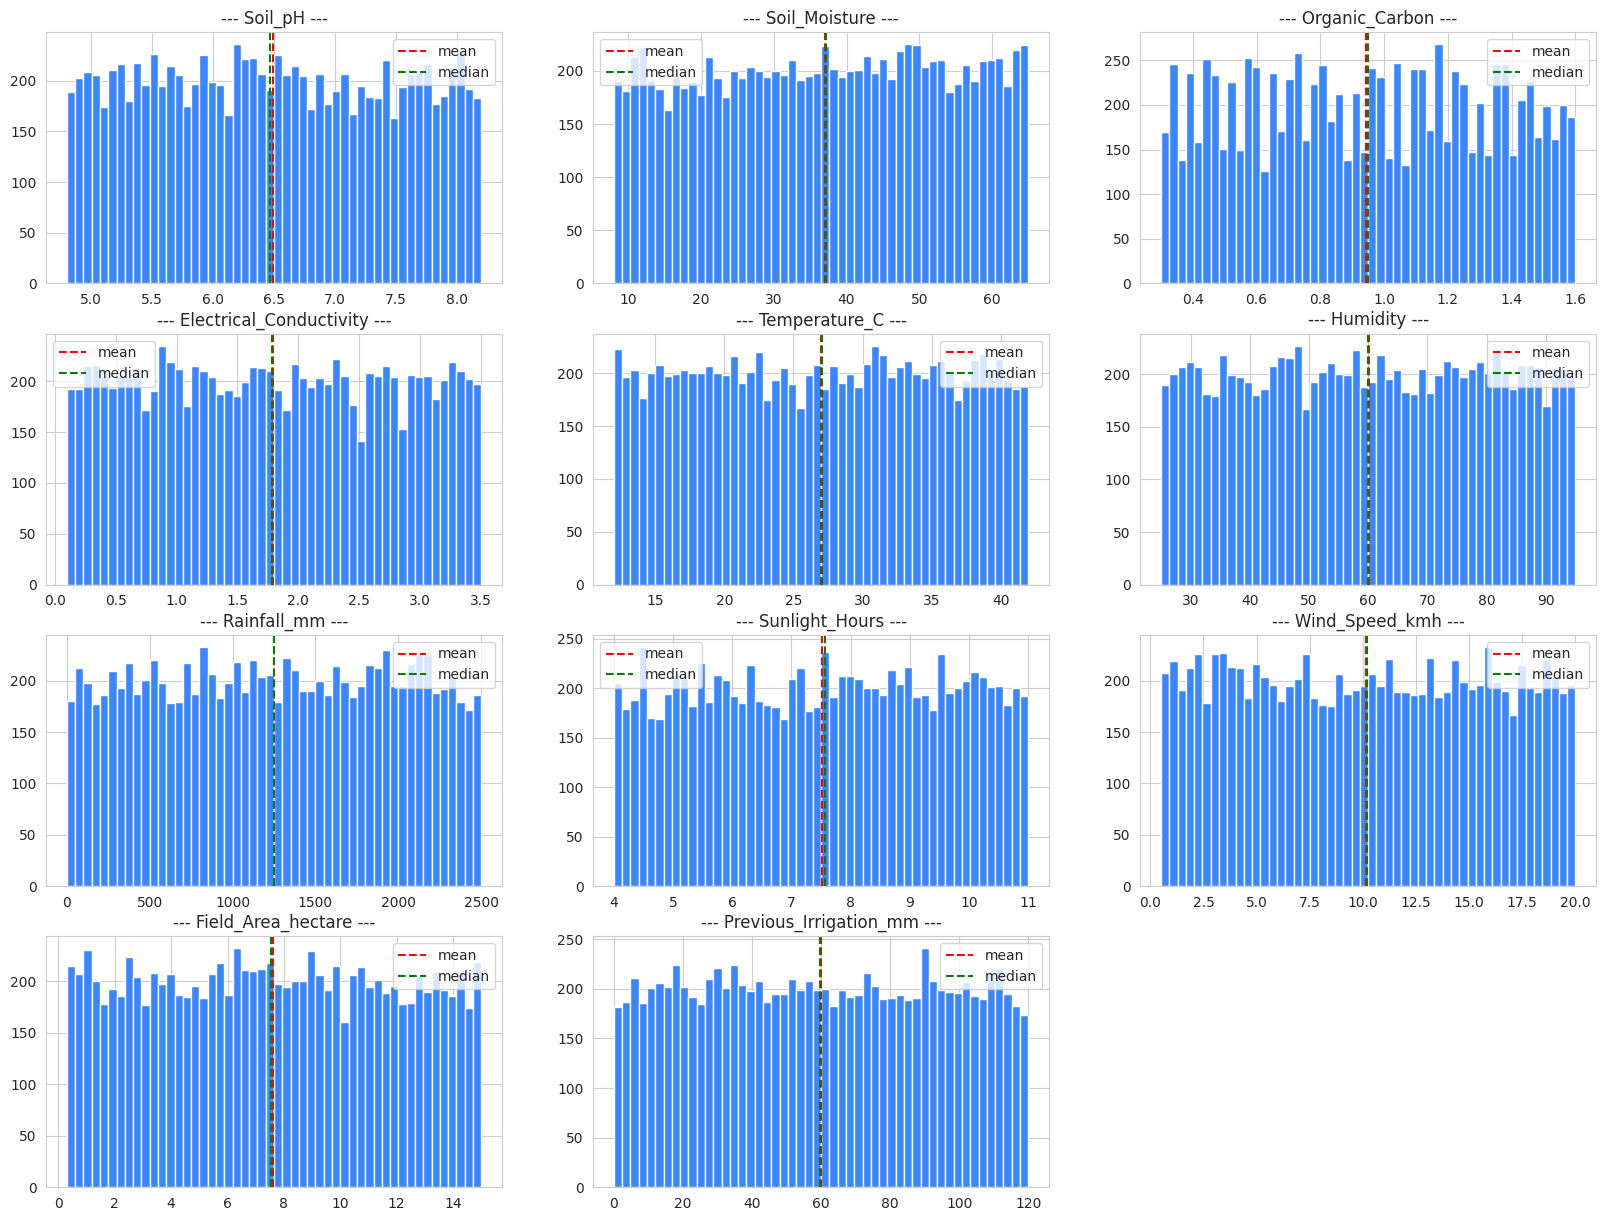

In [9]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='inferno')

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
Train,341,5223,131,341,2934,6475,19308,701,1935,1466,10110,4,6,4,3,4,4,2,5
Original,341,4751,131,341,2897,5305,9813,701,1937,1470,6843,4,6,4,3,4,4,2,5
Test,341,4963,131,341,2864,6149,14483,700,1922,1452,9338,4,6,4,3,4,4,2,5


## FEATURE ENGINEERING

In [11]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        sample_weights = np.array([opt[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    results = balanced_accuracy_score(y_true, pred_labels)
    return results

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [12]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    
    ## -- Compute Model Importances --
    print('Base  model training... ', end='')
    model.fit(X_train, y_train, sample_weight=get_weights(y_train, y))
    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    print('Complete!')

    ## -- Compute Permutation Importances --
    print('Permutation training... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, max_samples=0.8,
        sample_weight=get_weights(y_test, y),
        scoring='balanced_accuracy',
        random_state=42, n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(15, 8))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")
    
    axs[1].boxplot(
        result.importances[perm_sorted_idx].T, orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx], whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("Impurity-based vs. permutation importances on validation data")
    _ = fig.tight_layout()

print('Plot function script ready!')

Plot function script ready!


Base  model training... Complete!
Permutation training... Complete!
CPU times: user 35.1 s, sys: 174 ms, total: 35.3 s
Wall time: 56.9 s


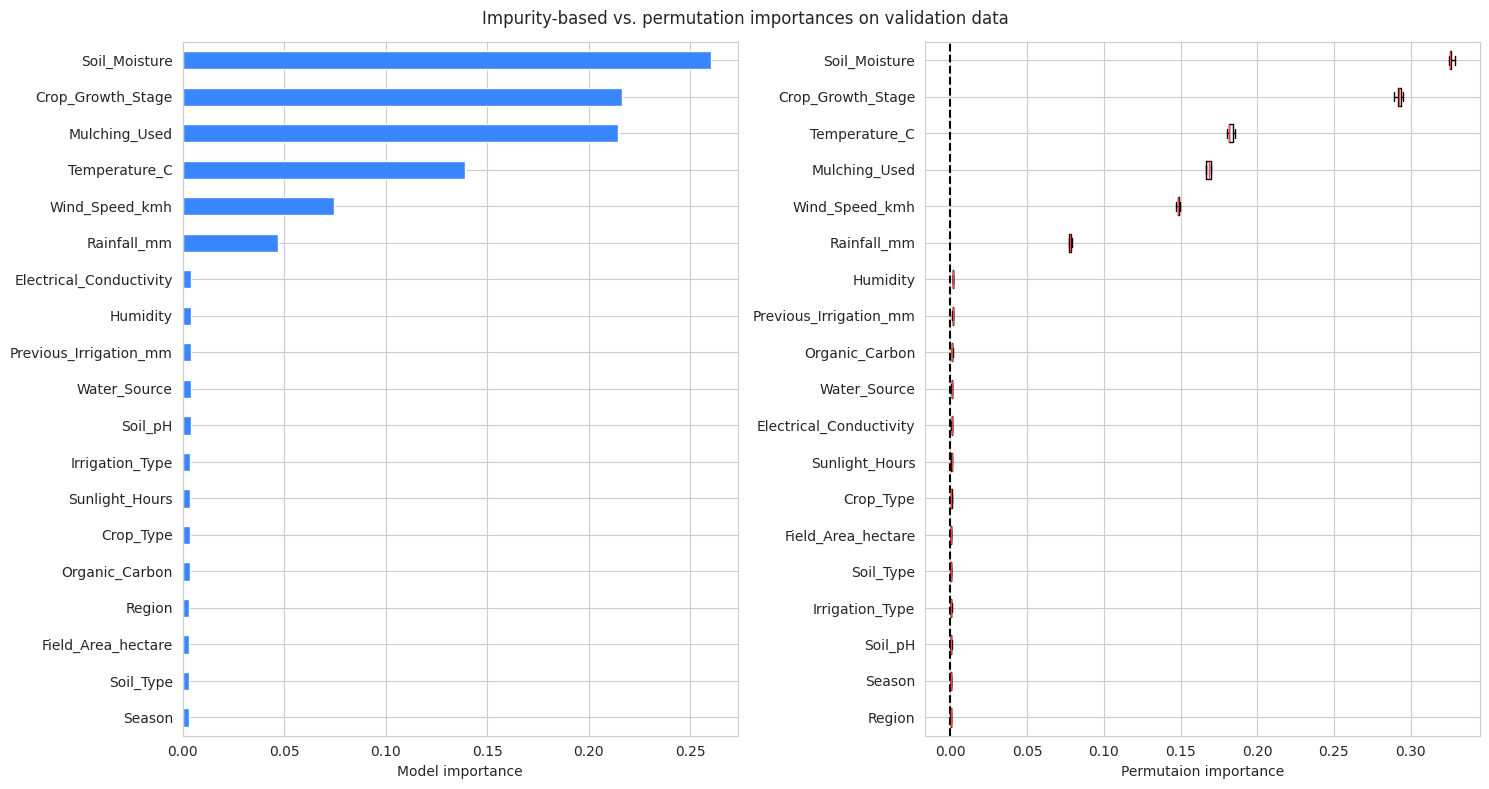

In [13]:
%%time 

PARAMS = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': 3,
    'enable_categorical': True,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

xgb_model = xgb.XGBClassifier(**PARAMS)

plot_permutation_importance(xgb_model, train[BASE], train[TARGET], CATS)

In [14]:
# %%time 
# from sklearn.inspection import permutation_importance

# PARAMS = {
#     'objective': 'multi:softprob',
#     'eval_metric': 'mlogloss',
#     'num_class': 3,
#     'enable_categorical': True,
#     'random_state': SEED,
#     'verbosity': 1,
#     'n_jobs': -1,
#     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# }

# X_1 = train[BASE]
# y_1 = train[TARGET]

# for c in CATS:
#     X_1[c] = X_1[c].factorize()[0]
#     X_1[c] = X_1[c].astype('category')

# x_tr = X_1.sample(frac=0.75, random_state=SEED)
# x_ts = X_1[~X_1.index.isin(x_tr.index)]

# y_tr = y_1.loc[x_tr.index]
# y_ts = y_1.loc[x_ts.index]

# print('Base model training... ', end='')
# model = xgb.XGBClassifier(**PARAMS).fit(x_tr, y_tr, sample_weight=get_weights(y_tr, y_tr))
# print("Complete!")

# print('Permutation training... ', end='')
# perm_importance = permutation_importance(
#     model,
#     x_ts,
#     y_ts,
#     n_repeats=5,
#     sample_weight=get_weights(y_ts, y_tr),
#     scoring='balanced_accuracy',
#     random_state=SEED,
#     n_jobs=-1,
# )
# print('Complete!')

# importance_df = pd.DataFrame({
#     'feature': BASE,
#     'importance': perm_importance.importances_mean
# }).sort_values(by='importance', ascending=False).reset_index(drop=True)

# top_n = 15

# plt.figure(figsize=(15, 8))
# sns.barplot(data=importance_df.head(top_n), x='importance', y='feature', palette='RdYlGn_r')
# plt.title('Top Predictive Drivers', fontsize=15)

# plt.tight_layout()
# plt.show()

# importance_df.style.background_gradient(cmap='RdYlGn')

In [15]:
# importance_sr = pd.Series(
#     index=BASE, name='importance',
#     data=perm_importance.importances_mean
# ).sort_values(ascending=False)

# importance_sr.sort_values().plot.barh()
# plt.show()

In [16]:
## -- Top/Low features according to PERMUTATION IMPORTANCES --
TOP_COLS = ['Soil_Moisture', 'Temperature_C',
            'Wind_Speed_kmh', 'Rainfall_mm',
            'Mulching_Used', 'Crop_Growth_Stage']

LOW_COLS = [c for c in BASE if c not in TOP_COLS]

print(f"Top Features by PI: {TOP_COLS}")
print(f"Low Features by PI: {LOW_COLS}")

Top Features by PI: ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm', 'Mulching_Used', 'Crop_Growth_Stage']
Low Features by PI: ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Humidity', 'Sunlight_Hours', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type', 'Crop_Type', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']


In [17]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_val   = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     # print(f'OptimalBinning {len(bin_features)}: ', end='')
#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train[new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_val[new_col]   = opt_multi_b.transform(x_val[col].to_numpy(),   metric=metric)
#         x_test[new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_val, x_test

# print('Binning function ready')

In [18]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [19]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [20]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [21]:
# BIN_TABLES[0].analysis()

In [22]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [23]:
FOUR_VALUES = ['Rainfall_mm']

print(f"\nEXTRACTING ROUNDS... ", end='')
for col in FOUR_VALUES:
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nCREATING E_BINS... ", end='')
    # for b in [400]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [1000]: # 100, 500, 1000
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... Rainfall_mm_round_-3, Rainfall_mm_round_-2, Rainfall_mm_round_-1, Rainfall_mm_round_0, Rainfall_mm_round_1, 
EXTRACTING DIGITS... Rainfall_mm_digit_-3, Rainfall_mm_digit_-2, Rainfall_mm_digit_-1, Rainfall_mm_digit_0, Rainfall_mm_digit_1, Rainfall_mm_digit_2, 
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 0
✅ TOTAL QUANTILE E_BINS: 0


In [24]:
THREE_VALUES = ['Previous_Irrigation_mm']

for col in THREE_VALUES:
    # print(f"\nROUNDING FEATURES... ", end='')
    # for r in [-2, -1, 0, 1]:
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)
    
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)
        
    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [500]: # 50, 100, 400
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


EXTRACTING DIGITS... Previous_Irrigation_mm_digit_-2, Previous_Irrigation_mm_digit_-1, Previous_Irrigation_mm_digit_0, Previous_Irrigation_mm_digit_1, Previous_Irrigation_mm_digit_2, 
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 5
✅ TOTAL EQUAL BINS: 0
✅ TOTAL QUANTILE BINS: 0


In [25]:
TOP_TWO_VALUES = ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh']

for col in TOP_TWO_VALUES:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... Soil_Moisture_round_-1, Soil_Moisture_round_0, Soil_Moisture_round_1, 
EXTRACTING DIGITS... Soil_Moisture_digit_-1, Soil_Moisture_digit_0, Soil_Moisture_digit_1, Soil_Moisture_digit_2, 
EXTRACTING ROUNDS... Temperature_C_round_-1, Temperature_C_round_0, Temperature_C_round_1, 
EXTRACTING DIGITS... Temperature_C_digit_-1, Temperature_C_digit_0, Temperature_C_digit_1, Temperature_C_digit_2, 
EXTRACTING ROUNDS... Wind_Speed_kmh_round_-1, Wind_Speed_kmh_round_0, Wind_Speed_kmh_round_1, 
EXTRACTING DIGITS... Wind_Speed_kmh_digit_-1, Wind_Speed_kmh_digit_0, Wind_Speed_kmh_digit_1, Wind_Speed_kmh_digit_2, 
✅ TOTAL ROUND FEATURES: 14        
✅ TOTAL DIGITS FEATURES: 23        
✅ TOTAL EQUAL BINS: 0         
✅ TOTAL QUANTILE BINS: 0         


In [26]:
TWO_VALUES = ['Humidity', 'Sunlight_Hours', 'Field_Area_hectare']

for col in TWO_VALUES:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    # for r in [-1, 0, 1]:
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... 
EXTRACTING DIGITS... Humidity_digit_-1, Humidity_digit_0, Humidity_digit_1, Humidity_digit_2, 
EXTRACTING ROUNDS... 
EXTRACTING DIGITS... Sunlight_Hours_digit_-1, Sunlight_Hours_digit_0, Sunlight_Hours_digit_1, Sunlight_Hours_digit_2, 
EXTRACTING ROUNDS... 
EXTRACTING DIGITS... Field_Area_hectare_digit_-1, Field_Area_hectare_digit_0, Field_Area_hectare_digit_1, Field_Area_hectare_digit_2, 
✅ TOTAL ROUND FEATURES: 14        
✅ TOTAL DIGITS FEATURES: 35        
✅ TOTAL EQUAL BINS: 0         
✅ TOTAL QUANTILE BINS: 0         


In [27]:
ONE_VALUE = ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']

for col in ONE_VALUE:
    # print(f"\nROUNDING... ", end='')
    # for r in [0, 1]:
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')

    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING DIGITS... Soil_pH_digit_0, Soil_pH_digit_1, Soil_pH_digit_2, 
EXTRACTING DIGITS... Organic_Carbon_digit_0, Organic_Carbon_digit_1, Organic_Carbon_digit_2, 
EXTRACTING DIGITS... Electrical_Conductivity_digit_0, Electrical_Conductivity_digit_1, Electrical_Conductivity_digit_2, 
✅ TOTAL ROUND FEATURES: 14        
✅ TOTAL DIGITS FEATURES: 44        
✅ TOTAL EQUAL BINS: 0         
✅ TOTAL QUANTILE BINS: 0         


In [28]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [29]:
def add_frequency_condition(df1, cols, thresh=5):
    df = df1.copy()
    for c in cols:
        # 1. Get value counts
        v_counts = df[c].value_counts()
        # 2. Identify values to replace (count <= threshold)
        to_replace = v_counts[v_counts <= thresh].index
        # 3. Apply condition: if value in low-freq list, assign 0, else keep it
        df[c] = np.where(df[c].isin(to_replace), -1, df[c])

    return df

for df in [train, test, orig]:
    df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

print(f"Frequency threshold imputed!")

Frequency threshold imputed!


In [30]:
# LOW_CATS_UNIQUE = []

# for col in ALL_ROUND_BINS:
#     if train[col].nunique() < 100:
#         LOW_CATS_UNIQUE.append(col)

# print(f"Cats with ~100 unique: {len(LOW_CATS_UNIQUE)}")
# print()
# TOP_CATS_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_CATS_UNIQUE]
# print(f"Cats with +100 unique: {len(TOP_CATS_UNIQUE)}")

In [31]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

# train[arithmetic].head()

In [32]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [33]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)

# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [34]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(TOP_COLS, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
    n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
    INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/15 [00:00<?, ?it/s]

Triplewise:   0%|          | 0/20 [00:00<?, ?it/s]

Total Interaction Features: 35


In [35]:
train[INTER].head()

,Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Temperature_C-|-Wind_Speed_kmh,Tri_Soil_Moisture-|-Temperature_C-|-Rainfall_mm,Tri_Soil_Moisture-|-Temperature_C-|-Mulching_Used,Tri_Soil_Moisture-|-Temperature_C-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Rainfall_mm-|-Mulching_Used,Tri_Soil_Moisture-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Temperature_C-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Temperature_C-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Temperature_C-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Temperature_C-|-Rainfall_mm-|-Mulching_Used,Tri_Temperature_C-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Temperature_C-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Mulching_Used,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Rainfall_mm-|-Mulching_Used-|-Crop_Growth_Stage
0,32.58_15.01,32.58_16.79,32.58_725.99,32.58_No,32.58_Sowing,15.01_16.79,15.01_725.99,15.01_No,15.01_Sowing,16.79_725.99,16.79_No,16.79_Sowing,725.99_No,725.99_Sowing,No_Sowing,32.58_15.01_16.79,32.58_15.01_725.99,32.58_15.01_No,32.58_15.01_Sowing,32.58_16.79_725.99,32.58_16.79_No,32.58_16.79_Sowing,32.58_725.99_No,32.58_725.99_Sowing,32.58_No_Sowing,15.01_16.79_725.99,15.01_16.79_No,15.01_16.79_Sowing,15.01_725.99_No,15.01_725.99_Sowing,15.01_No_Sowing,16.79_725.99_No,16.79_725.99_Sowing,16.79_No_Sowing,725.99_No_Sowing
1,56.61_22.92,56.61_3.39,56.61_985.66,56.61_Yes,56.61_Vegetative,22.92_3.39,22.92_985.66,22.92_Yes,22.92_Vegetative,3.39_985.66,3.39_Yes,3.39_Vegetative,985.66_Yes,985.66_Vegetative,Yes_Vegetative,56.61_22.92_3.39,56.61_22.92_985.66,56.61_22.92_Yes,56.61_22.92_Vegetative,56.61_3.39_985.66,56.61_3.39_Yes,56.61_3.39_Vegetative,56.61_985.66_Yes,56.61_985.66_Vegetative,56.61_Yes_Vegetative,22.92_3.39_985.66,22.92_3.39_Yes,22.92_3.39_Vegetative,22.92_985.66_Yes,22.92_985.66_Vegetative,22.92_Yes_Vegetative,3.39_985.66_Yes,3.39_985.66_Vegetative,3.39_Yes_Vegetative,985.66_Yes_Vegetative
2,27.71_26.97,27.71_3.85,27.71_2201.7,27.71_Yes,27.71_Vegetative,26.97_3.85,26.97_2201.7,26.97_Yes,26.97_Vegetative,3.85_2201.7,3.85_Yes,3.85_Vegetative,2201.7_Yes,2201.7_Vegetative,Yes_Vegetative,27.71_26.97_3.85,27.71_26.97_2201.7,27.71_26.97_Yes,27.71_26.97_Vegetative,27.71_3.85_2201.7,27.71_3.85_Yes,27.71_3.85_Vegetative,27.71_2201.7_Yes,27.71_2201.7_Vegetative,27.71_Yes_Vegetative,26.97_3.85_2201.7,26.97_3.85_Yes,26.97_3.85_Vegetative,26.97_2201.7_Yes,26.97_2201.7_Vegetative,26.97_Yes_Vegetative,3.85_2201.7_Yes,3.85_2201.7_Vegetative,3.85_Yes_Vegetative,2201.7_Yes_Vegetative
3,13.32_13.32,13.32_2.31,13.32_1357.33,13.32_Yes,13.32_Flowering,13.32_2.31,13.32_1357.33,13.32_Yes,13.32_Flowering,2.31_1357.33,2.31_Yes,2.31_Flowering,1357.33_Yes,1357.33_Flowering,Yes_Flowering,13.32_13.32_2.31,13.32_13.32_1357.33,13.32_13.32_Yes,13.32_13.32_Flowering,13.32_2.31_1357.33,13.32_2.31_Yes,13.32_2.31_Flowering,13.32_1357.33_Yes,13.32_1357.33_Flowering,13.32_Yes_Flowering,13.32_2.31_1357.33,13.32_2.31_Yes,13.32_2.31_Flowering,13.32_1357.33_Yes,13.32_1357.33_Flowering,13.32_Yes_Flowering,2.31_1357.33_Yes,2.31_1357.33_Flowering,2.31_Yes_Flowering,1357.33_Yes_Flowering
4,59.14_20.22,59.14_13.94,59.14_1538.2,59.14_No,59.14_Sowing,20.22_13.94,20.22_1538.2,20.22_No,20.22_Sowing,13.94_1538.2,13.94_No,13.94_Sowing,1538.2_No,1538.2_Sowing,No_S

In [36]:
sleep(2); gc.collect()

17459

In [37]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [39]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [40]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [41]:
## -- BINARY FORMULA --
def add_FE_formula(df1):
    df = df1.copy()

    # 4 Boolean numeric features based on threshold insights
    df['soil_lt_25']  = (df['Soil_Moisture'] < 25).astype('int8')  # <25
    df['temp_gt_30']  = (df['Temperature_C'] > 30).astype('int8')  # >30
    df['rain_lt_300'] = (df['Rainfall_mm'] < 300).astype('int8')   # <300
    df['wind_gt_10']  = (df['Wind_Speed_kmh'] > 10).astype('int8') # >10
    return df

train = add_FE_formula(train)
test  = add_FE_formula(test)
orig  = add_FE_formula(orig)

FORMULA_FLAGS = train.columns.tolist()[-4:]
print(f"Formula flags: {FORMULA_FLAGS}")


## -- LOGIT FORMULA --
for df_ in [train, test]:
    df = pd.get_dummies(df_, columns=CATS, drop_first=False)

    df_['logit(P(y=Low))'] = 16.3173 + (-11.0237 * df["soil_lt_25"]) + (-5.8559 * df["temp_gt_30"]) + (-10.8500 * df["rain_lt_300"]) + (-5.8284 * df["wind_gt_10"]) + (-5.4155 * df["Crop_Growth_Stage_Flowering"]) + (5.5073 * df["Crop_Growth_Stage_Harvest"]) + (5.2299 * df["Crop_Growth_Stage_Sowing"]) + (-5.4617 * df["Crop_Growth_Stage_Vegetative"]) + (-3.0014 * df["Mulching_Used_No"]) + (2.8613 * df["Mulching_Used_Yes"])
    df_['logit(P(y=Medium))'] = 4.6524 + (0.3290 * df["soil_lt_25"]) + (-0.0204 * df["temp_gt_30"]) + (0.1542 * df["rain_lt_300"]) + (0.0841 * df["wind_gt_10"]) + (0.3586 * df["Crop_Growth_Stage_Flowering"]) + (-0.1348 * df["Crop_Growth_Stage_Harvest"]) + (-0.3547 * df["Crop_Growth_Stage_Sowing"]) + (0.3334 * df["Crop_Growth_Stage_Vegetative"]) + (0.1883 * df["Mulching_Used_No"]) + (0.0142 * df["Mulching_Used_Yes"])
    df_['logit(P(y=High))'] = -20.9697 + (10.6947 * df["soil_lt_25"]) + (5.8763 * df["temp_gt_30"]) + (10.6958 * df["rain_lt_300"]) + (5.7444 * df["wind_gt_10"]) + (5.0569 * df["Crop_Growth_Stage_Flowering"]) + (-5.3725 * df["Crop_Growth_Stage_Harvest"]) + (-4.8752 * df["Crop_Growth_Stage_Sowing"]) + (5.1283 * df["Crop_Growth_Stage_Vegetative"]) + (2.8131 * df["Mulching_Used_No"]) + (-2.8755 * df["Mulching_Used_Yes"])

LOGIT_COLS = ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']
print(f"Formula logit: {LOGIT_COLS}")

train[FORMULA_FLAGS+LOGIT_COLS].head()

Formula flags: ['soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10']
Formula logit: ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']


,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High))
0,0,0,0,1,12.7174,4.5701,-17.2874
1,0,0,0,0,13.7169,5.0000,-18.7169
2,0,0,0,0,13.7169,5.0000,-18.7169
3,1,0,0,0,2.7394,5.3542,-8.0936
4,0,0,0,1,12.7174,4.5701,-17.2874


In [42]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [43]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [44]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 119


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Rainfall_mm_round_-3,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Rainfall_mm_round_1,Rainfall_mm_digit_-3,Rainfall_mm_digit_-2,Rainfall_mm_digit_-1,Rainfall_mm_digit_0,Rainfall_mm_digit_1,Rainfall_mm_digit_2,Previous_Irrigation_mm_digit_-2,Previous_Irrigation_mm_digit_-1,Previous_Irrigation_mm_digit_0,Previous_Irrigation_mm_digit_1,Previous_Irrigation_mm_digit_2,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_round_1,Soil_Moisture_digit_-1,Soil_Moisture_digit_0,Soil_Moisture_digit_1,Soil_Moisture_digit_2,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_round_1,Temperature_C_digit_-1,Temperature_C_digit_0,Temperature_C_digit_1,Temperature_C_digit_2,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_round_1,Wind_Speed_kmh_digit_-1,Wind_Speed_kmh_digit_0,Wind_Speed_kmh_digit_1,Wind_Speed_kmh_digit_2,Humidity_digit_-1,Humidity_digit_0,Humidity_digit_1,Humidity_digit_2,Sunlight_Hours_digit_-1,Sunlight_Hours_digit_0,Sunlight_Hours_digit_1,Sunlight_Hours_digit_2,Field_Area_hectare_digit_-1,Field_Area_hectare_digit_0,Field_Area_hectare_digit_1,Field_Area_hectare_digit_2,Soil_pH_digit_0,Soil_pH_digit_1,Soil_pH_digit_2,Organic_Carbon_digit_0,Organic_Carbon_digit_1,Organic_Carbon_digit_2,Electrical_Conductivity_digit_0,Electrical_Conductivity_digit_1,Electrical_Conductivity_digit_2,Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Temperature_C-|-Wind_Speed_kmh,Tri_Soil_Moisture-|-Temperature_C-|-Rainfall_mm,Tri_Soil_Moisture-|-Temperature_C-|-Mulching_Used,Tri_Soil_Moisture-|-Temperature_C-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Rainfall_mm-|-Mulching_Used,Tri_Soil_Moisture-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Temperature_C-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Temperature_C-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Temperature_C-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Temperature_C-|-Rainfall_mm-|-Mulching_Used,Tri_Temperature_C-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Temperature_C-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Mulching_Used,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Rainfall_mm-|-Mulching_Used-|-Crop_Growth_Stage,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,logit(P(y=Low)),logit(P(y=Medium)),logit(P(y=High))
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0,0,0,0,0,0.82,0,112.16,0,0,1000,700,730,726,726,0,7,2,5,9,9,1,1,2,1,6,30,33,32,3,2,5,8,20,15,15,1,5,0,1,20,17,16,1,6,7,9,5,0,6,1,0,5,9,0,0,0,8,2,4,9,2,1,0,1,3,0,5,32.58_15.01,32.58_16.79,32.58_725.99,32.58_No,32.58_Sowing,15.01_16.79,15.01_725.99,15.01_No,15.01_Sowing,16.79_725.99,16.79_No,16.79_Sowing,725.99_No,725.99_Sowing,No_Sowing,32.58_15.01_16.79,32.58_15.01_725.99,32.58_15.01_No,32.58_15.01_Sowing,32.58_16.79_725.99,32.58_16.79_No,32.58_16.79_Sowing,32.58_725.99_No,32.58_725.99_Sowing,32.58_No_Sowing,15.01_16.79_725.99,15.01_16.79_No,15.01_16.79_Sowing,15.01_725.99_No,15.01_725.99_Sowing,15.01_No_Sowing,16.79_725.99_No,16.79_725.99_Sowing,16.79_No_Sowing,725.99_No_Sowi

# ML TRAINING

In [45]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_classes = y.nunique()

    class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}
    
    oof_preds = np.zeros((len(train_df), num_classes))
    test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []
    
    calib_oof_preds = np.zeros((len(train_df), num_classes))
    calib_test_preds = np.zeros((len(test_df), num_classes))
    calib_fold_scores = []

    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

        ## -- Split data for the current fold
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # print(f"CategoryMeanEncoding: {len(cats)}")
        # cm_enc  = CategoryMeanTransformer(cat_cols=cats)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_val   = cm_enc.transform(X_val).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, OPT_COLS, X_train, X_val, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_val,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100, 
        #     # period=300,
        # )

        combined = pd.concat([X_train, X_val, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        ## -- Target Encoding -- 
        TE_COLS = ROUNDS + INTER + DIGITS #+ OPT_COLS #+ CATS_2
        print(f" • Target Encoding {len(TE_COLS)} features... ")

        te_enc = TargetEncoder(target_type='multiclass', cv=5, random_state=SEED)
        train_enc = te_enc.fit_transform(X_train[TE_COLS], y_train).astype('float32')
        val_enc   = te_enc.transform(X_val[TE_COLS]).astype('float32')
        test_enc  = te_enc.transform(X_test[TE_COLS]).astype('float32')
        ## -- Assign names for TE columns --
        rename_cols = [f'TE_{col}' for col in train_enc.columns]
        train_enc.columns = rename_cols
        test_enc.columns  = rename_cols
        val_enc.columns   = rename_cols
        ## -- Merge TE features back to dataset, drop old features --
        X_train = pd.concat([X_train, train_enc], axis=1).drop(columns=TE_COLS).copy()
        X_val   = pd.concat([X_val,   val_enc],   axis=1).drop(columns=TE_COLS).copy()
        X_test  = pd.concat([X_test,  test_enc],  axis=1).drop(columns=TE_COLS).copy()

        ## -- Internal Split for Calibration --
        X_train_base, X_train_calib, y_train_base, y_train_calib = train_test_split(
            X_train, y_train, train_size=0.7, stratify=y_train, random_state=SEED
        )

        print(f' • Training base model {X_train_base.shape}... ')
        # display(X_train_base.head(3))

        xgb_model = xgb.XGBClassifier(
            **params, num_class=num_classes,
            callbacks=[xgb.callback.EarlyStopping(rounds=100)],
        )

        xgb_model.fit(
            X_train_base, y_train_base, 
            sample_weight=get_weights(y_train_base, y_train),
            eval_set=[(X_val, y_val)], verbose=250,
        )

        feat_importances.append(xgb_model.feature_importances_.ravel())

        oof_preds[val_idx] = xgb_model.predict_proba(X_val)
        test_preds += xgb_model.predict_proba(X_test)

        fold_score = balanced_acc(y_val, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{YELLOW}Score: {fold_score:.5f}{RESET}')

        ## -- Calibrate for "true" probabilities --
        print(f' • Training calibration model {X_train_calib.shape}... ', end='')
    
        calib_model = CalibratedClassifierCV(FrozenEstimator(xgb_model), cv=None,
                                             method='isotonic', n_jobs=-1)

        calib_model.fit(X_train_calib, y_train_calib,
            sample_weight=get_weights(y_train_calib, y_train))

        calib_oof_preds[val_idx] = calib_model.predict_proba(X_val)
        calib_test_preds += calib_model.predict_proba(X_test)
        
        calib_fold_score = balanced_acc(y_val, calib_oof_preds[val_idx])
        calib_fold_scores.append(calib_fold_score)
        print(f'{YELLOW}Score: {calib_fold_score:.5f}{RESET}')

    # Average test predictions
    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
        print(f" • FOLD {i}: xgb -> {b:.5f} | calib -> {c:.5f}")

    overall_score = np.round(balanced_acc(y, oof_preds), 5)
    calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)
    
    print(f"{'='*40}")
    print(f"OOF:  XGB -> {overall_score} | CALIB -> {calib_overall_score}")
    print(f"{'-'*40}")
    print(f"AVG  Base: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
    print(f"{'-'*40}")
    print(f"{GREEN}Improved:  {calib_overall_score - overall_score:.5f}{RESET}")
    print(f"{'='*40}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'scores': [overall_score, calib_overall_score],
        'models': xgb_model,
        'oof_preds': [oof_preds, calib_oof_preds],
        'test_preds': [test_preds, calib_test_preds],
        'importances': feat_importances,
        'val_data': [X_val, y_val],
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [46]:
version_name = 'xgb_v2_'

all_model_predictions = {}

ALL_CATS = CATS

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [47]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_model_predictions:
# #     all_model_predictions.clear()

# M_NAME = version_name #'Trial_'
# COMPILER = []

# OUT_LOOP = [3.0, 4.0, 5.0]
# INN_LOOP = [0]
# p_name   = ['gamma', '-']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f">>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'sampling_method': 'gradient_based',
#             # # ----------------------------------
#             # 'grow_policy': 'lossguide',
#             # 'max_leaves': 32,
#             'max_depth': 4,
#             # # ----------------------------------
#             'objective': 'multi:softprob',
#             'eval_metric': 'mlogloss',
#             # 'n_estimators': 10_000,
#             'learning_rate': 0.1,
#             'subsample': 0.9,
#             'colsample_bytree': 0.2,
#             # 'reg_alpha': outer,
#             # 'reg_lambda': inner,
#             'gamma': outer,
#             # 'max_bin': 1024,
#             # 'min_child_weight': inner,
#             'enable_categorical': True,
#             'random_state': SEED,
#             'verbosity': 0,
#             'n_jobs': -1,
#             'device': 'cuda' if torch.cuda.is_available() else 'cpu',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=ALL_CATS,
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} model(s) ======\n")

In [48]:
# ----- base + formula_flag + TE(ROUNDS+DIGITS+INTER(top2_top3_top2low))
# ==================================================
#  • FOLD 1: xgb -> 0.97595 | calib -> 0.97881
#  • FOLD 2: xgb -> 0.97624 | calib -> 0.97990
#  • FOLD 3: xgb -> 0.97851 | calib -> 0.98126
#  • FOLD 4: xgb -> 0.97614 | calib -> 0.97956
#  • FOLD 5: xgb -> 0.97647 | calib -> 0.97981
# ========================================
# OOF:  XGB -> 0.97666 | CALIB -> 0.97987
# ----------------------------------------
# AVG  Base: 0.97666 ± 0.00094
# AVG Calib: 0.97987 ± 0.00080
# ----------------------------------------
# Improved: 0.00321
# ========================================
# 49.47 mins


In [49]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'scores':
#                 all_model_scores[model_name] = value

# raw_scores, calib_scores, names = [], [], []

# for k, group in all_model_scores.items():
#     raw_scores.append(group[0])
#     calib_scores.append(group[1])
#     names.append(k)

# plt.figure(figsize=(15, 6))
# ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
# ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

# y_add = 1e-3

# for i, s1 in enumerate(raw_scores):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

# for i, s2 in enumerate(calib_scores):
#     ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

# plt.ylim((0.97, 0.99))
# plt.legend(loc='upper center')
# plt.xticks(range(len(names)), names, rotation=30)
# plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

# plt.tight_layout() 
# plt.show()

In [50]:
# all_feat_importances = {}
# all_val_data = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'importances':
#                 all_feat_importances[model_name] = np.mean(value, axis=0)
#             elif key == 'val_data':
#                 all_val_data[model_name] = value 

# top_n = 25

# for i, (m, fi) in enumerate(all_feat_importances.items()):
#     fi_df = pd.DataFrame({
#         'feature': all_val_data[m][0].columns, # -> [0] select X_val, [1] select y_val
#         'importance': fi,
#     }).sort_values(by='importance', ascending=False).reset_index(drop=True)

#     plt.figure(figsize=(15, 7*len(all_feat_importances)))
#     # plt.subplot(len(all_feat_importances), 1, i+1)
#     sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
#     plt.title(f'{m} Avg. {N_SPLITS}-Fold Feature Importances', fontweight='semibold')

#     plt.tight_layout() 
#     plt.show()

#     print()

In [51]:
LR = 0.05
L1 = 0.0
L2 = 0.0
DEPTH = 4
GAMMA = 0.05
MIN_WEIGHT = 1
CALIBRATE  = 'iso2'

In [52]:
# ## ======= BOOSTING =========
# M_NAME = f"{version_name}gbt_"

# PARAMS = {
#     'objective': 'multi:softprob',
#     'eval_metric': 'mlogloss',
#     'n_estimators': 10_000,
#     'max_depth': DEPTH,
#     'learning_rate': LR,
#     'subsample': 0.9,
#     'colsample_bytree': 0.2,
#     'reg_alpha': L1,
#     'reg_lambda': L2,
#     'gamma': GAMMA,
#     'min_child_weight': MIN_WEIGHT,
#     'enable_categorical': True,
#     'random_state': SEED,
#     'verbosity': 0,
#     'n_jobs': -1,
#     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# }

# n = M_NAME + CALIBRATE
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# # for value in [3, 4]:
# #     PARAMS['max_depth'] = value
# #     n = M_NAME + str(value)
# #     all_model_predictions[n] = Trainer_CV(
# #         model_name=n,
# #         params=PARAMS,
# #         train_df=train,
# #         test_df=test,
# #         features=FEATURES,
# #         target=TARGET,
# #         kf=kf,
# #         cats=ALL_CATS,
# #     )

In [53]:
# ==================================================
# Cross-Validation Results for xgb_v0_gbt_isotonic
# ==================================================
#  • FOLD 1: xgb -> 0.97657 | calib -> 0.97950
#  • FOLD 2: xgb -> 0.97652 | calib -> 0.97999
#  • FOLD 3: xgb -> 0.97889 | calib -> 0.98125
#  • FOLD 4: xgb -> 0.97652 | calib -> 0.98006
#  • FOLD 5: xgb -> 0.97623 | calib -> 0.98033
# ========================================
# OOF:  XGB -> 0.97694 | CALIB -> 0.98022
# ----------------------------------------
# AVG  Base: 0.97694 ± 0.00098
# AVG Calib: 0.98022 ± 0.00058
# ----------------------------------------
# Improved:  0.00328
# ========================================
# 160.62 mins

In [54]:
## ======= LOSS GUIDE =========
M_NAME = f"{version_name}loss_"
LEAVES = 32

PARAMS = {
    # ----------------------------------
    'grow_policy': 'lossguide',
    'max_leaves': LEAVES,
    'max_depth': 0,
    # ----------------------------------
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'n_estimators': 5000,
    'learning_rate': LR,
    'subsample': 0.9,
    'colsample_bytree': 0.2,
    'reg_alpha': L1,
    'reg_lambda': L2,
    'gamma': GAMMA,
    'min_child_weight': MIN_WEIGHT,
    'enable_categorical': True,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME + str(LEAVES)
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

# for value in [3, 4]:
#     PARAMS['max_depth'] = value
#     n = M_NAME + str(value)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=ALL_CATS,
#     )


========== Starting Cross-Validation for xgb_v2_loss_32 ==========

***** FOLD 1/10 *****
 • Target Encoding 93 features... 
 • Training base model (396900, 305)... 
[0]	validation_0-mlogloss:1.03155
[250]	validation_0-mlogloss:0.05339
[500]	validation_0-mlogloss:0.04986
[750]	validation_0-mlogloss:0.04897
[985]	validation_0-mlogloss:0.04887
Score: 0.97422
 • Training calibration model (170100, 305)... Score: 0.97801

***** FOLD 2/10 *****
 • Target Encoding 93 features... 
 • Training base model (396900, 305)... 
[0]	validation_0-mlogloss:1.03144
[250]	validation_0-mlogloss:0.05153
[500]	validation_0-mlogloss:0.04772
[750]	validation_0-mlogloss:0.04677
[1000]	validation_0-mlogloss:0.04660
[1037]	validation_0-mlogloss:0.04662
Score: 0.97455
 • Training calibration model (170100, 305)... Score: 0.97667

***** FOLD 3/10 *****
 • Target Encoding 93 features... 
 • Training base model (396900, 305)... 
[0]	validation_0-mlogloss:1.03150
[250]	validation_0-mlogloss:0.05253
[500]	validation_

In [55]:
# ## ======= GRADIENT-BASED =========
# M_NAME = f"{version_name}grad_"

# PARAMS = {
#     'sampling_method': 'gradient_based',
#     # ------------------------------------
#     'objective': 'multi:softprob',
#     'eval_metric': 'mlogloss',
#     'n_estimators': 10_000,
#     'learning_rate': LR,
#     'max_depth': DEPTH,
#     'subsample': 0.9,
#     'colsample_bytree': 0.2,
#     'reg_alpha': L1,
#     'reg_lambda': L2,
#     'gamma': GAMMA,
#     'min_child_weight': MIN_WEIGHT,
#     'enable_categorical': True,
#     'random_state': SEED,
#     'verbosity': 0,
#     'n_jobs': -1,
#     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# }

# n = M_NAME + str(LR).split('.')[1]
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=ALL_CATS,
# )

# # for value in [3, 4]:
# #     PARAMS['max_depth'] = value
# #     n = M_NAME + str(value)
# #     all_model_predictions[n] = Trainer_CV(
# #         model_name=n,
# #         params=PARAMS,
# #         train_df=train,
# #         test_df=test,
# #         features=FEATURES,
# #         target=TARGET,
# #         kf=kf,
# #         cats=ALL_CATS,
# #     )

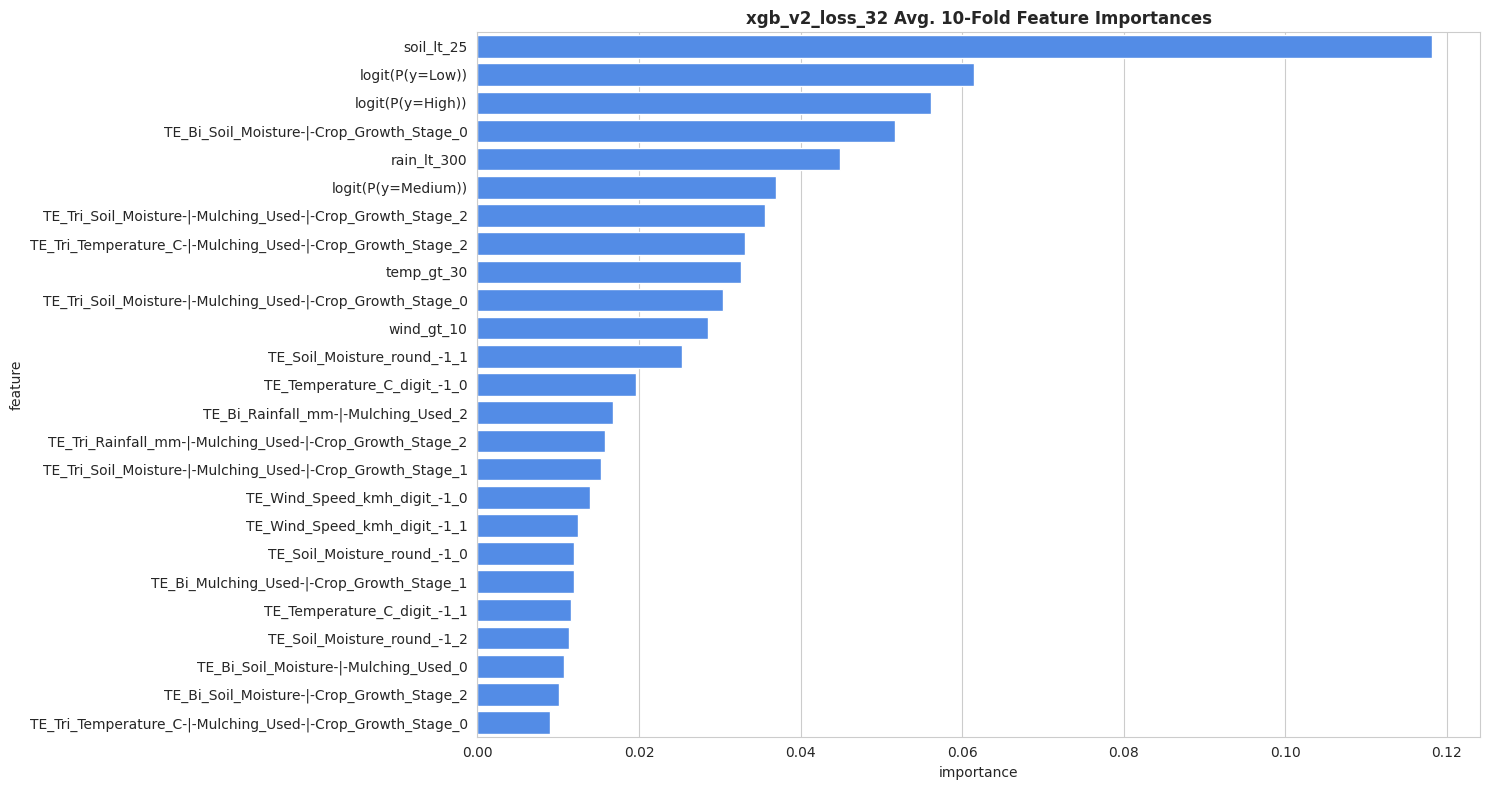

In [56]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'importances':
            all_feat_importances[k] = np.mean(y, axis=0)
        elif x == 'val_data':
            all_val_data[k] = y # -> [0] select X_val, [1] select y_val

top_n = 25

for i, (m, fi) in enumerate(all_feat_importances.items()):
    fi_df = pd.DataFrame({
        'feature': all_val_data[m][0].columns,
        'importance': fi,
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(15, 8*len(all_feat_importances)))
    plt.subplot(len(all_feat_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
    plt.title(f'{m} Avg. {N_SPLITS}-Fold Feature Importances', fontweight='semibold')

    plt.tight_layout() 
    plt.show()

    print()

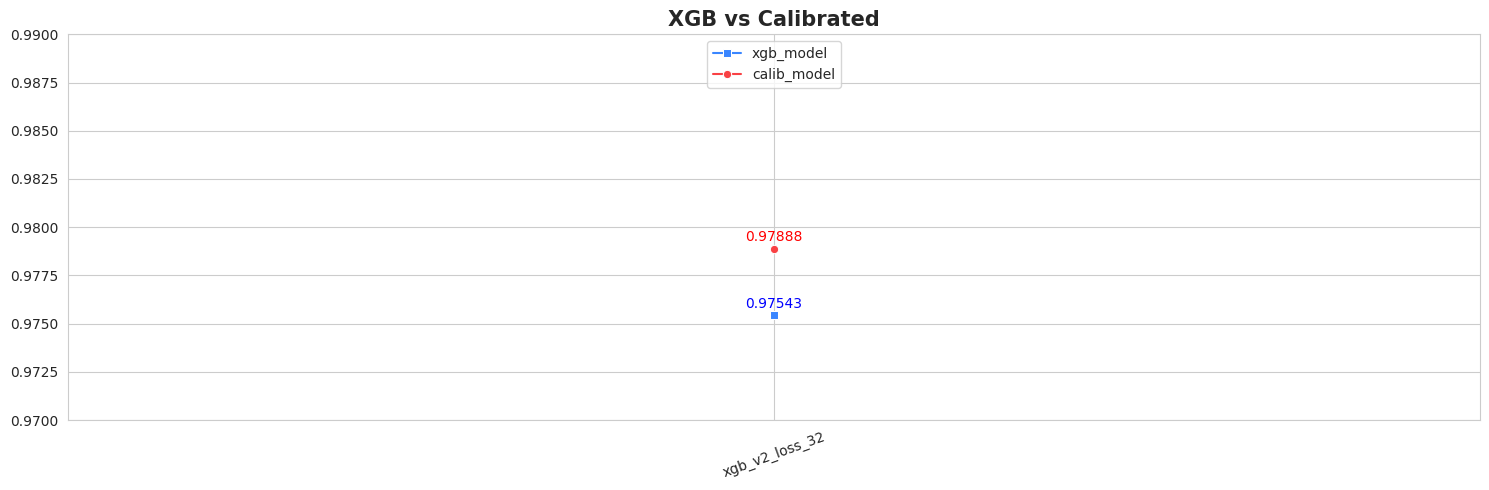

In [57]:
all_model_scores = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_model_scores[k] = y

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group[0])
    calib_scores.append(group[1])
    names.append(k)

plt.figure(figsize=(15, 5))
ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

y_add = 4e-4

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

for i, s2 in enumerate(calib_scores):
    ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

plt.ylim((0.97, 0.99))
plt.legend(loc='upper center')
plt.xticks(range(len(names)), names, rotation=20)
plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

In [58]:
# !rm -r /kaggle/working

In [59]:
## -- Get OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            base_n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_base_{base_n}_.npy", y[0])
            print(f'OOF file for base model saved!')

            ## -- Create calib submission file --
            cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"oof_calib_{cal_n}_.npy", y[1])
            print(f'OOF file for calibrated model saved!')
            
            print()

OOF file for base model saved!
OOF file for calibrated model saved!



In [60]:
## -- Get TEST PREDICTIONS / SUBMISSIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            base_n_1 = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_base_{base_n_1}_.npy", y[0])
            base_preds = np.argmax(y[0], axis=1)
            submit[TARGET] = pd.Series(base_preds).map(mapping_r)
            submit.to_csv(f'submit_base_{base_n_1}_.csv', index=False)
            print(f'Submission base TEST file saved! {base_preds.shape}')

            ## -- Calib submission file --
            cal_n_1 = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"test_calib_{cal_n_1}_.npy", y[1])
            calib_preds = np.argmax(y[1], axis=1)
            submit[TARGET] = pd.Series(calib_preds).map(mapping_r)
            submit.to_csv(f'submit_calib_{cal_n_1}_.csv', index=False)
            print(f'Submission calib TEST file saved! {calib_preds.shape}')

            print()

Submission base TEST file saved! (270000,)
Submission calib TEST file saved! (270000,)



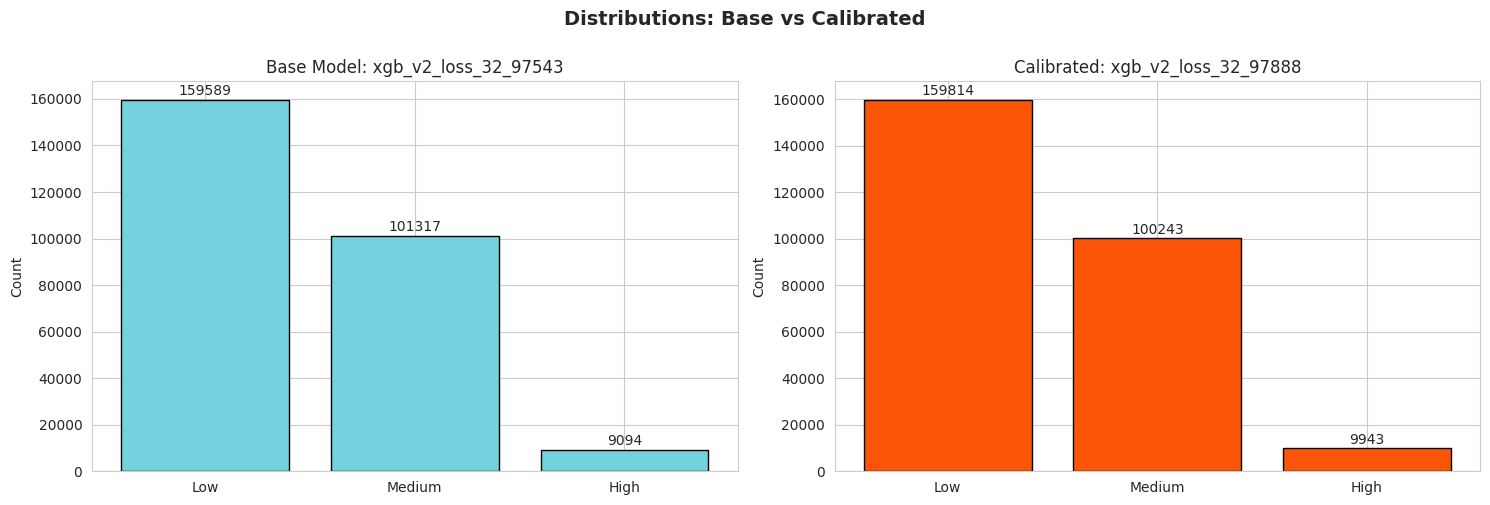

In [61]:
class_names = [k for k in mapping.keys()]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], base_preds, f'Base Model: {base_n_1}', '#73D2DE'),
    (axes[1], calib_preds, f'Calibrated: {cal_n_1}', '#FB5607'),
]:
    counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
    ax.bar(class_names, counts, color=color, edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')

    for i, c in enumerate(counts):
        ax.text(i, c+2000, str(c), ha='center', fontsize=10)

plt.suptitle('Distributions: Base vs Calibrated', fontsize=14, y=1.00, fontweight='semibold')

plt.tight_layout()
plt.show()